# Sentiment Analysis of IMDb Movie Reviews

This notebook performs sentiment analysis on the IMDb movie review dataset. We will go through data loading, preprocessing, exploratory data analysis, feature engineering, model training with traditional machine learning algorithms (Logistic Regression and SVM), hyperparameter tuning, and model evaluation.

In [ ]:
import re
import nltk
import numpy as np
import pandas as pd
import tensorflow as tf
import seaborn as sns
import matplotlib.pyplot as plt
from nltk.corpus import stopwords
from tensorflow.keras.models import Sequential
from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.layers import Activation,Dense, Dropout
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.layers import Flatten,GlobalMaxPooling1D,Conv1D, Embedding, LSTM

### Custom Text Preprocessing Utilities

In [2]:
nltk.download('stopwords')
stopwords_list = set(stopwords.words('english'))
TAG_RE = re.compile(r'<[^>]+>')
def remove_tags(text):
    return TAG_RE.sub('', text)
class CustomPreprocess():
    def __init__(self):
        pass
    def preprocess_text(self,sen):
        sen = sen.lower()
        # Remove html tags
        sentence = remove_tags(sen)
        # Remove punctuations and numbers
        sentence = re.sub('[^a-zA-Z]', ' ', sentence)
        # Single character removal
        sentence = re.sub(r"\s+[a-zA-Z]\s+", ' ', sentence)
        # Remove multiple spaces
        sentence = re.sub(r'\s+', ' ', sentence)
        # Remove Stopwords
        pattern = re.compile(r'\b(' + r'|'.join(stopwords_list) + r')\b\s*')
        sentence = pattern.sub('', sentence)

        return sentence

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


In [3]:
custom = CustomPreprocess()
custom.preprocess_text("I thought this was a wonderful way to spend time on a too hot summer weekend")

'thought wonderful way spend time hot summer weekend'

In [4]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


### Data Loading and Extraction

We will mount Google Drive to access the dataset and then unzip it into a local directory.

In [5]:
file_path = '/content/drive/My Drive/IMDb Movie Review Dataset.zip'


In [6]:
extract_dir = '/content/imdb_dataset'
!mkdir -p "{extract_dir}"
!unzip -o "{file_path}" -d "{extract_dir}"

print(f"Dataset unzipped to: {extract_dir}")

# List the contents of the extracted directory
print("Contents of the extracted directory:")
!ls -F "{extract_dir}"

Archive:  /content/drive/My Drive/IMDb Movie Review Dataset.zip
  inflating: /content/imdb_dataset/IMDB Dataset.csv  
Dataset unzipped to: /content/imdb_dataset
Contents of the extracted directory:
'IMDB Dataset.csv'


The dataset is now unzipped. Let's load the `IMDB Dataset.csv` file into a pandas DataFrame and inspect its first few rows.

In [7]:
df=pd.read_csv('../content/imdb_dataset/IMDB Dataset.csv')

### Initial Data Inspection

Displaying the first few rows to understand the data structure.

In [8]:
df.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


### Data Information

Checking the data types and non-null counts for each column to identify any missing values or incorrect types.

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   review     50000 non-null  object
 1   sentiment  50000 non-null  object
dtypes: object(2)
memory usage: 781.4+ KB


### Checking for Null Values

Confirming there are no missing values in the dataset.

In [ ]:
df.isnull().sum()

,0
review,0
sentiment,0


### Sentiment Distribution

Analyzing the distribution of positive and negative sentiments in the dataset.

In [ ]:
df["sentiment"].value_counts()

,count
sentiment,
positive,25000
negative,25000


### Visualizing Sentiment Distribution

A countplot to visually represent the balance between positive and negative reviews.

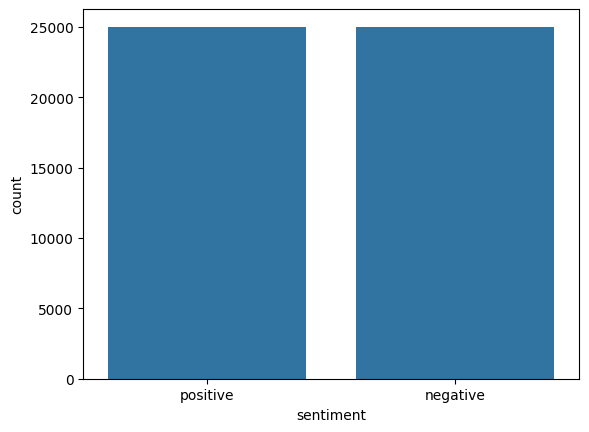

In [10]:
sns.countplot(data = df, x = df["sentiment"])
plt.show()

### Text Preprocessing

Applying a custom preprocessing function to clean the movie reviews. This includes removing HTML tags, punctuation, numbers, single characters, and stopwords. We also encode the sentiment to numerical values (0 for negative, 1 for positive).

In [11]:
df['cleaned_review'] = df['review'].apply(custom.preprocess_text)

df['sentiment_encoded'] = df['sentiment'].apply(lambda x: 1 if x == 'positive' else 0) #LABEL ENCODER

print("First 5 rows with cleaned review and encoded sentiment:")
display(df.head())

First 5 rows with cleaned review and encoded sentiment:


,review,sentiment,cleaned_review,sentiment_encoded
0,One of the other reviewers has mentioned that ...,positive,one reviewers mentioned watching oz episode ho...,1
1,A wonderful little production. <br /><br />The...,positive,wonderful little production filming technique ...,1
2,I thought this was a wonderful way to spend ti...,positive,thought wonderful way spend time hot summer we...,1
3,Basically there's a family where a little boy ...,negative,basically family little boy jake thinks zombie...,0
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive,petter mattei love time money visually stunnin...,1


### Review Length Analysis

Comparing the distribution of original and cleaned review lengths to see the effect of preprocessing.

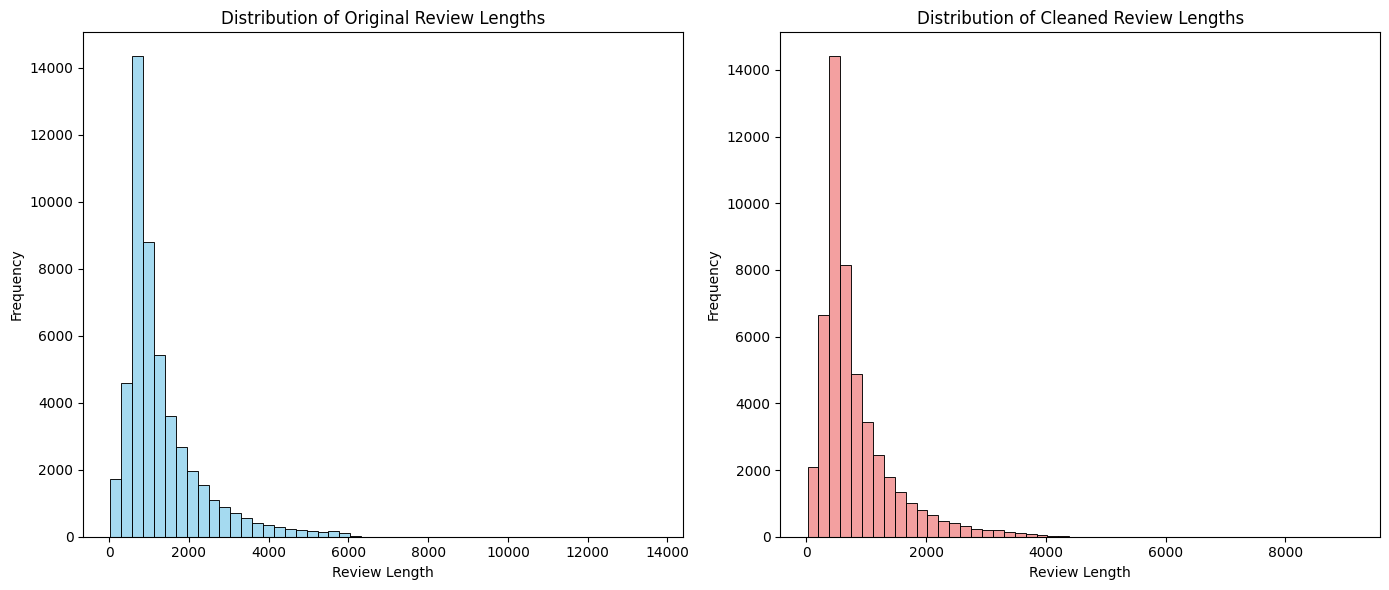

In [ ]:
df['original_review_length'] = df['review'].apply(len)
df['cleaned_review_length'] = df['cleaned_review'].apply(len)

plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
sns.histplot(df['original_review_length'], bins=50, color='skyblue')
plt.title('Distribution of Original Review Lengths')
plt.xlabel('Review Length')
plt.ylabel('Frequency')

plt.subplot(1, 2, 2)
sns.histplot(df['cleaned_review_length'], bins=50, color='lightcoral')
plt.title('Distribution of Cleaned Review Lengths')
plt.xlabel('Review Length')
plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

The review length distribution is positively skewed, indicating that most reviews are relatively short while a smaller subset contains very long detailed opinions.

In [13]:
df['cleaned_review'].duplicated().sum()

np.int64(425)

In [14]:
df.drop_duplicates(subset=['cleaned_review'], inplace=True)
print(f"DataFrame shape after removing duplicates: {df.shape}")

DataFrame shape after removing duplicates: (49575, 4)


### Exploratory Data Analysis: Word Cloud of Common Words

A word cloud provides a visual representation of the most frequent words in our preprocessed reviews. This can give us insights into the common themes and topics.

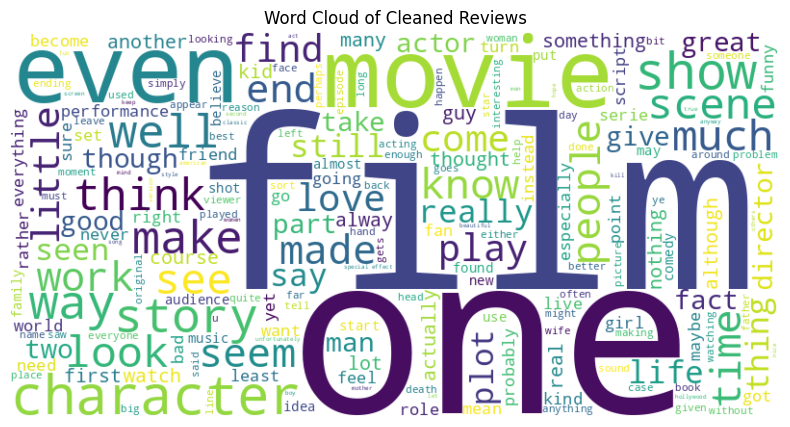

In [ ]:
from wordcloud import WordCloud

# Combine all cleaned reviews into a single string
all_words = ' '.join(df['cleaned_review'].dropna())

# Generate word cloud
wordcloud = WordCloud(width=800, height=400, background_color='white').generate(all_words)

plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud of Cleaned Reviews')
plt.show()

### Feature Engineering: Tokenization Parameters

Defining the maximum number of words for the tokenizer and performing tokenization and sequence padding for consistent input length for the models.

### Feature Engineering: Tokenization, Padding, and Train-Test Split

Now, let's prepare our text data for a deep learning model. This involves:
1.  **Splitting** the dataset into training and testing sets.
2.  **Tokenizing** the cleaned reviews to convert words into numerical representations.
3.  **Padding** the sequences to ensure all input sequences have a consistent length, which is required by neural networks.

In [19]:
# Split data into training and testing sets
X = df['cleaned_review']
y = df['sentiment_encoded']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training data shape: {X_train.shape}")
print(f"Testing data shape: {X_test.shape}")

Training data shape: (39660,)
Testing data shape: (9915,)


In [20]:
max_words = 10000  # Considering top 10,000 words
tokenizer = Tokenizer(num_words=max_words, oov_token='<OOV>')

# Fit tokenizer on training texts
tokenizer.fit_on_texts(X_train)

# Convert texts to sequences of integers
X_train_sequences = tokenizer.texts_to_sequences(X_train)
X_test_sequences = tokenizer.texts_to_sequences(X_test)

print("Example of a tokenized review (first training sample):")
print(X_train_sequences[0][:10]) # Display first 10 tokens

Example of a tokenized review (first training sample):
[729, 726, 979, 39, 661, 138, 858, 2333, 15, 729]


### TF-IDF Vectorization

Converting the text data into numerical TF-IDF (Term Frequency-Inverse Document Frequency) features. TF-IDF reflects how important a word is to a document in a corpus.

In [21]:
from sklearn.feature_extraction.text import TfidfVectorizer

# Instantiate TfidfVectorizer
tfidf_vectorizer = TfidfVectorizer(max_features=max_words)

# Fit on X_train and transform both X_train and X_test
X_train_tfidf = tfidf_vectorizer.fit_transform(X_train)
X_test_tfidf = tfidf_vectorizer.transform(X_test)

print(f"Shape of X_train_tfidf: {X_train_tfidf.shape}")
print(f"Shape of X_test_tfidf: {X_test_tfidf.shape}")

Shape of X_train_tfidf: (39660, 10000)
Shape of X_test_tfidf: (9915, 10000)


### Model Evaluation Function

Defining a utility function to train a given model, make predictions, and report key performance metrics like accuracy, precision, recall, F1-score, and display a confusion matrix.

In [22]:
import matplotlib.pyplot as plt

from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

def evaluate_model(model, model_name,
                   X_train, X_test,
                   y_train, y_test):

    # Train
    model.fit(X_train, y_train)

    # Predict
    y_pred = model.predict(X_test)

    # Metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    # Print results
    print(f"\n{'='*40}")
    print(f"{model_name}")
    print(f"{'='*40}")

    print(f"Accuracy  : {accuracy:.4f}")
    print(f"Precision : {precision:.4f}")
    print(f"Recall    : {recall:.4f}")
    print(f"F1 Score  : {f1:.4f}")

    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)

    fig, ax = plt.subplots(figsize=(6,5))

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=["Negative", "Positive"]
    )

    disp.plot(
        cmap="Blues",
        values_format="d",
        ax=ax
    )

    plt.title(f"{model_name} - Confusion Matrix")
    plt.show()

    return {
        "Model": model_name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1": f1
    }

### Training Logistic Regression Model

Applying Logistic Regression, a simple yet effective linear model for binary classification, to our TF-IDF features.


Logistic Regression
Accuracy  : 0.8958
Precision : 0.8860
Recall    : 0.9122
F1 Score  : 0.8989


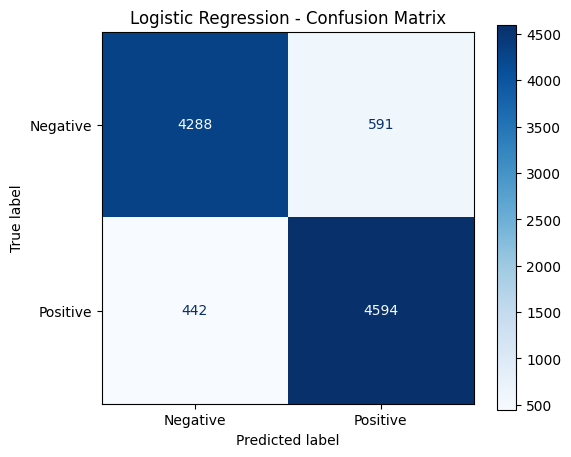

In [23]:
from sklearn.linear_model import LogisticRegression

log_model = LogisticRegression(max_iter=1000)

log_result = evaluate_model(
    log_model,
    "Logistic Regression",
    X_train_tfidf,
    X_test_tfidf,
    y_train,
    y_test
)

### Training Support Vector Machine (SVM) Model

Applying a Linear Support Vector Classifier (LinearSVC) to the TF-IDF features.


SVM
Accuracy  : 0.8880
Precision : 0.8835
Recall    : 0.8979
F1 Score  : 0.8907


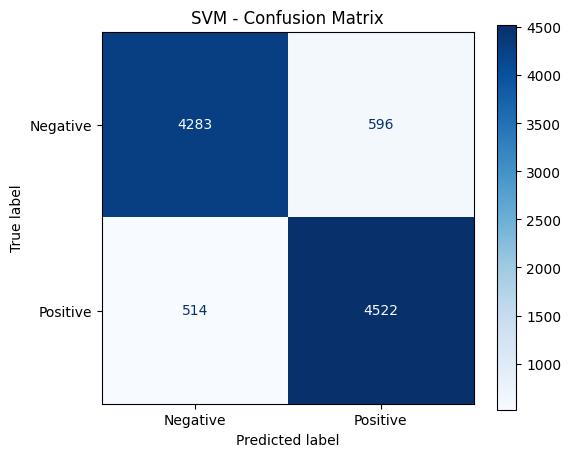

In [24]:
from sklearn.svm import LinearSVC

svm_model = LinearSVC()

svm_result = evaluate_model(
    svm_model,
    "SVM",
    X_train_tfidf,
    X_test_tfidf,
    y_train,
    y_test
)

### Hyperparameter Tuning for SVM using GridSearchCV

Optimizing the `C` parameter for the LinearSVC model using GridSearchCV to find the best performing hyperparameters.

In [25]:
from sklearn.svm import LinearSVC
from sklearn.model_selection import GridSearchCV

# Parameters to search
param_grid = {
    "C": [0.0001,0.001, 0.01, 0.1, 1, 10, 100]
}

# Grid Search
grid_svm = GridSearchCV(
    estimator=LinearSVC(),
    param_grid=param_grid,
    cv=5,
    scoring="f1",
    n_jobs=-1
)

# Train
grid_svm.fit(
    X_train_tfidf,
    y_train
)

# Results
print("Best Parameters:")
print(grid_svm.best_params_)

print("\nBest CV F1:")
print(grid_svm.best_score_)

Best Parameters:
{'C': 0.1}

Best CV F1:
0.8931699627361132


### Evaluating Optimized SVM Model

Training and evaluating the SVM model with the best hyperparameters found through GridSearchCV.


Optimized SVM
Accuracy  : 0.8972
Precision : 0.8869
Recall    : 0.9142
F1 Score  : 0.9004


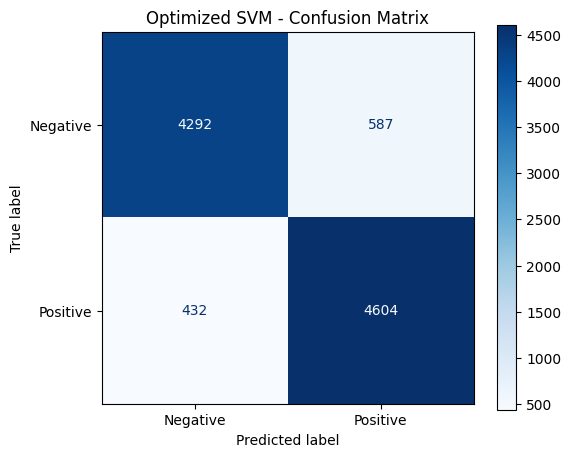

In [26]:
best_svm = LinearSVC(
    C=grid_svm.best_params_["C"]
)

best_svm_result = evaluate_model(
    best_svm,
    "Optimized SVM",
    X_train_tfidf,
    X_test_tfidf,
    y_train,
    y_test
)

### Comparing Model Performance

Presenting a summary of the F1-scores and other metrics for both Logistic Regression and the Optimized SVM.

In [27]:
final_results = pd.DataFrame([
    log_result,
    best_svm_result
])

print(
    final_results.sort_values(
        by="F1",
        ascending=False
    )
)

                 Model  Accuracy  Precision    Recall        F1
1        Optimized SVM  0.897226   0.886920  0.914218  0.900362
0  Logistic Regression  0.895814   0.886017  0.912232  0.898934


### Calculating Improvement

Quantifying the improvement in F1-score of the optimized SVM over the baseline Logistic Regression model.

In [28]:
improvement = (
    (best_svm_result["F1"] - log_result["F1"])
    / log_result["F1"]
) * 100

print(f"Improvement: {improvement:.2f}%")

Improvement: 0.16%


### Saving the Trained Model and Vectorizer

Persisting the best performing model (Optimized SVM) and the TF-IDF vectorizer to disk for future use, avoiding retraining.

In [ ]:
import joblib

# Save trained model
joblib.dump(
    best_svm,
    "best_svm_sentiment.pkl"
)
joblib.dump(
    log_model,
    "log_model_sentiment.pkl"
)

# Save TF-IDF vectorizer
joblib.dump(
    tfidf_vectorizer,
    "tfidf_vectorizer.pkl"
)

print("Saved successfully")

Saved successfully


### Loading the Saved Model and Vectorizer

Loading the previously saved model and vectorizer to demonstrate their use for new predictions.

In [ ]:
best_model = joblib.load(
    "best_svm_sentiment.pkl"
)

log_model = joblib.load(
    "log_model_sentiment.pkl"
)

vectorizer = joblib.load(
    "tfidf_vectorizer.pkl"
)

### Making a Prediction on a New Review

Demonstrating how to use the loaded model to predict the sentiment of a new, unseen movie review.

In [ ]:
review = [
      """I think the subject matter isn't appropriate for young children because they wouldn't understand anything thats going on and would be asking you questions, get bored fidget and they wouldn't enjoy it at all. For older teenagers, they might find it a little interesting but again, I believe they would grow bored with it. For adults, they probably wouldn't understand anything thats going on and they'd get bored and wouldn't enjoy it at all! First of all, the movie is shot with blurred images so you never see clear, crisp full normal color images on the screen. It reminded me of horror movies where everything is blurry and dark. Dark overtones on the colors erode the quality of the colors and they are like one would be swimming underwater in murky waters. The music is so highly annoying, it helps to destoy the viewer's interest and enjoyment of the film. It sounds like Yanni on a warped record and the same stanzas repeat over and over until you want to vomit! In fact, Yanni's music put to this movie would have been much more enjoyable. But the music goes on and on throughout the entire film; it never varies and gets extremely repetitive and irritating. The music keeps building and building and rarely reaches a crescendo. The film makers apparently thought it would add suspense but it doesn't. It just makes you nauseous. The actors and actresses you're given very little background information about them and everything is piecemeal about their lives so their characters never fully develop and they remain strangers to the viewer, and they live convoluted non-sensical lives. The beginning of the movie throws you into a scene with the viewer wondering "huh?" And throughout the film, the viewer finds himself repeating "huh" like a mantra. It never gets any better. The film ends and you still are saying "huh?" to yourself. A very dissapointing film considering there were a few good actors but their quality of their acting skills wasn't allowed to be displayed; the movie could have had unknown actors who would have served perfectly well to fill their roles. There was no sex, no violence, no cursing. And the theme of being reunited with his daughter gets real old quick. You'd think they would have delved deeper into the scientific aspects of the film but it is all in a haze and never clear to the viewer exactly what is going on. The ending was a big dissapointment too - I won't spoil it but I'll put it this way: I wouldn't waste your time or money going to see this film. You'll be yawning after the first 15 minutes! There was absolutely nothing exciting or interesting about this film, period!"""
 ]

review_tfidf = vectorizer.transform(
    review
)

pred = best_model.predict(
    review_tfidf
)

print(
    "Positive"
    if pred[0] == 1
    else "Negative"
)

Negative


In [ ]:
review_lengths = [len(x) for x in X_train_sequences]

print(np.percentile(review_lengths, 90))
print(np.percentile(review_lengths, 95))

232.0
305.0


95% of reviews were under 350 tokens,
therefore max_len=350 was selected.

Long reviews increase:

* memory usage
* training time
* padding inefficiency

### Padding Sequences

Ensuring all sequences have a uniform length by padding or truncating them. This is crucial for neural network inputs.

In [ ]:
def preprocess_for_dl(text):
    text = text.lower()
    text = remove_tags(text)
    text = re.sub('[^a-zA-Z]', ' ', text)
    text = re.sub(r'\s+', ' ', text)
    return text

df['dl_review'] = df['review'].apply(preprocess_for_dl)

In [ ]:
X_dl = df['dl_review']
y_dl = df['sentiment_encoded']

X_train_dl, X_test_dl, y_train_dl, y_test_dl = train_test_split(
    X_dl, y_dl, test_size=0.2, random_state=42
)

In [ ]:
max_words = 10000
tokenizer_dl = Tokenizer(num_words=max_words, oov_token='<OOV>')
tokenizer_dl.fit_on_texts(X_train_dl)

X_train_seq = tokenizer_dl.texts_to_sequences(X_train_dl)
X_test_seq = tokenizer_dl.texts_to_sequences(X_test_dl)

In [ ]:
max_len = 350

X_train_padded = pad_sequences(
    X_train_seq, maxlen=max_len, padding='post', truncating='post'
)

X_test_padded = pad_sequences(
    X_test_seq, maxlen=max_len, padding='post', truncating='post'
)

In [ ]:
vocab_size = max_words;
print(vocab_size)

10000


In [ ]:
# # Determine maximum sequence length
# max_len_org = max([len(x) for x in X_train_sequences])
# print(f"Maximum sequence length in training data: {max_len_org}")

# max_len=350;

# # Pad sequences to ensure uniform length
# X_train_padded = pad_sequences(X_train_sequences, maxlen=max_len, padding='post', truncating='post')
# X_test_padded = pad_sequences(X_test_sequences, maxlen=max_len, padding='post', truncating='post')

# print(f"Shape of padded training sequences: {X_train_padded.shape}")
# print(f"Shape of padded testing sequences: {X_test_padded.shape}")
# print("Example of a padded review (first training sample):")
# print(X_train_padded[0]);

Maximum sequence length in training data: 1401
Shape of padded training sequences: (40000, 350)
Shape of padded testing sequences: (10000, 350)
Example of a padded review (first training sample):
[ 657 1984   33 1724 1852 4140 6265  653 4645    1  121 5950   19  636
   26    4 1831   27   42  969 2186 1031  331  418  763  282    1   60
 2796    1 4177 2758  115   14   45 2961  127  310   97 4747   11    4
    1   15  245    3   97  191    1    1 1684 9851   39  296    1    1
 1516    1  440  302  260   40   38  248    1 6602  244    1 1013    1
    1    1  340  111  861 3983   76  316  556  484  128   35  701  114
  306  247    7 3556  165    1   63 1537   88    1    1  586 1768 1045
 2699    1 3532 1517    1  122  101  208  920 2652 8473 8964 3833    2
  844    1  365 2430  137   16   33   33  554 9713    1 1198  120 4178
    1  103  991 4200 5070    1 2139    1    1  321  487  578 2776 1115
    1 3431   60 1344 1084 1450  733 1092  186 2715  289  490  155 3374
  846    1 1104  112   

In [ ]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay
)

import matplotlib.pyplot as plt
import numpy as np


def evaluate_dl_model(
    model,
    model_name,
    X_train,
    X_test,
    y_train,
    y_test,
    epochs=5,
    batch_size=128
):

    # =========================
    # Train
    # =========================

    history = model.fit(

        X_train,
        y_train,

        validation_split=0.2,

        epochs=epochs,

        batch_size=batch_size,

        verbose=1
    )

    # =========================
    # Predict
    # =========================

    pred_probs = model.predict(X_test)

    preds = (
        pred_probs > 0.5
    ).astype(int)

    preds = preds.flatten()

    # =========================
    # Metrics
    # =========================

    accuracy = accuracy_score(
        y_test,
        preds
    )

    precision = precision_score(
        y_test,
        preds
    )

    recall = recall_score(
        y_test,
        preds
    )

    f1 = f1_score(
        y_test,
        preds
    )

    print(f"\n{'='*40}")
    print(model_name)
    print(f"{'='*40}")

    print(f"Accuracy  : {accuracy:.4f}")
    print(f"Precision : {precision:.4f}")
    print(f"Recall    : {recall:.4f}")
    print(f"F1 Score  : {f1:.4f}")

    # =========================
    # Confusion Matrix
    # =========================

    cm = confusion_matrix(
        y_test,
        preds
    )

    fig, ax = plt.subplots(
        figsize=(6,5)
    )

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=["Negative", "Positive"]
    )

    disp.plot(
        cmap="Blues",
        values_format="d",
        ax=ax
    )

    plt.title(
        f"{model_name} - Confusion Matrix"
    )

    plt.show()

    # =========================
    # Accuracy Plot
    # =========================

    plt.plot(
        history.history['accuracy']
    )

    plt.plot(
        history.history['val_accuracy']
    )

    plt.title(
        f"{model_name} Accuracy"
    )

    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")

    plt.legend([
        'Train',
        'Validation'
    ])

    plt.show()

    # =========================
    # Loss Plot
    # =========================

    plt.plot(
        history.history['loss']
    )

    plt.plot(
        history.history['val_loss']
    )

    plt.title(
        f"{model_name} Loss"
    )

    plt.xlabel("Epoch")
    plt.ylabel("Loss")

    plt.legend([
        'Train',
        'Validation'
    ])

    plt.show()

    return {
        "Model": model_name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1": f1
    }

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Conv1D, GlobalMaxPooling1D, Dense, Dropout

def build_conv1d_model():
    model = Sequential([
        Embedding(input_dim=vocab_size, output_dim=32, input_length=max_len),
        Conv1D(filters=64, kernel_size=5, activation='relu'),
        GlobalMaxPooling1D(),
        Dense(32, activation='relu'),
        Dropout(0.5),
        Dense(1, activation='sigmoid')
    ])

    model.compile(
        optimizer='adam',
        loss='binary_crossentropy',
        metrics=['accuracy']
    )
    return model

Epoch 1/5


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


250/250 ━━━━━━━━━━━━━━━━━━━━ 6s 12ms/step - accuracy: 0.6918 - loss: 0.5620 - val_accuracy: 0.8375 - val_loss: 0.3726
Epoch 2/5
250/250 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.8744 - loss: 0.3126 - val_accuracy: 0.8776 - val_loss: 0.2862
Epoch 3/5
250/250 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.9271 - loss: 0.2091 - val_accuracy: 0.8867 - val_loss: 0.2776
Epoch 4/5
250/250 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.9582 - loss: 0.1350 - val_accuracy: 0.8867 - val_loss: 0.3036
Epoch 5/5
250/250 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.9789 - loss: 0.0787 - val_accuracy: 0.8871 - val_loss: 0.3299
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step

Conv1D
Accuracy  : 0.8844
Precision : 0.8832
Recall    : 0.8881
F1 Score  : 0.8856


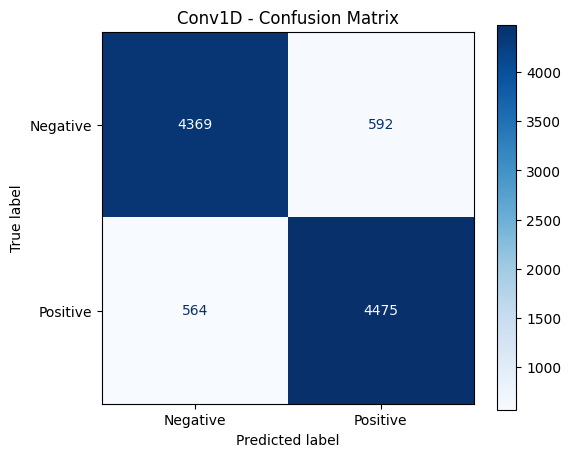

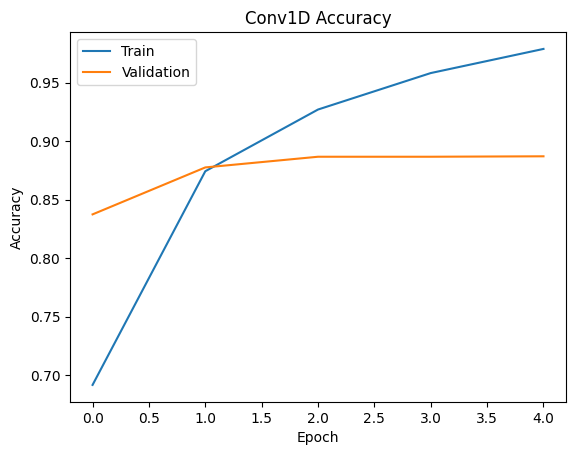

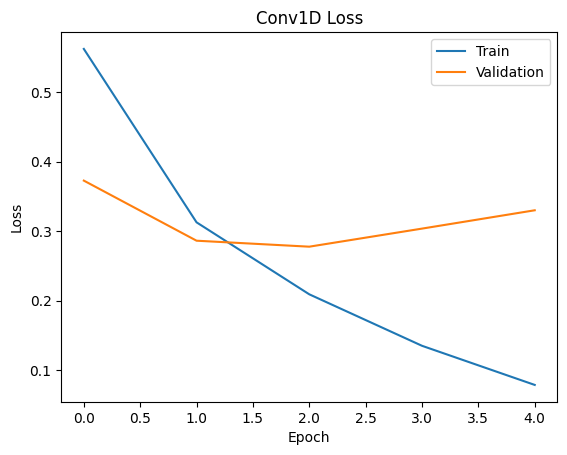

In [ ]:
conv_model = build_conv1d_model()

conv_result = evaluate_dl_model(
    conv_model,
    "Conv1D",
    X_train_padded,
    X_test_padded,
    y_train_dl,
    y_test_dl,
    epochs=5,
    batch_size=128
)